In [55]:
import xarray as xr
import rioxarray 
import matplotlib.pyplot as plt
import numpy as np

from pyproj import Transformer
from scipy.interpolate import griddata

## import cartopy for plotting
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from pyproj import CRS

In [56]:
target1 = "/Users/asgerthormann/Documents/uni/master/master_code/data/Model data - grid info/BCC-CSM-MR/proj_ssp126/tas_Amon_BCC-CSM2-MR_ssp126_r1i1p1f1_gn_201501-210012.nc"

target_1 = xr.open_dataset(target1)
target_1

<xarray.Dataset> Size: 211MB
Dimensions:    (time: 1032, bnds: 2, lat: 160, lon: 320)
Coordinates:
  * time       (time) object 8kB 2015-01-16 12:00:00 ... 2100-12-16 12:00:00
  * lat        (lat) float64 1kB -89.14 -88.03 -86.91 ... 86.91 88.03 89.14
  * lon        (lon) float64 3kB 0.0 1.125 2.25 3.375 ... 356.6 357.8 358.9
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 17kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 5kB ...
    tas        (time, lat, lon) float32 211MB ...
Attributes: (12/49)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          Standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  2015.0
    comment:                This is an extension of historical simulation (r1...
    ...                     ...
    title:                  BCC-CSM2-MR output prepared for CMIP6
    tracking_id:            hdl:21.14100/378373ed-a6ac-46dc-b13b-2d59c11b6391
    variable_id:            tas
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by BCC is licensed unde...
    cmor_version:           3.3.2

In [66]:
crs = CRS.from_epsg(32633)
print(crs)                  # human-readable summary: axes, datum, area of use
crs.to_dict()                # PROJ params as a dict
crs.axis_info                # axis order/units — this is where lat/lon-swap bugs come from
crs.area_of_use              # bounding box this CRS is valid/accurate for

EPSG:32633


AreaOfUse(west=12.0, south=0.0, east=18.0, north=84.0, name='Between 12°E and 18°E, northern hemisphere between equator and 84°N, onshore and offshore. Austria. Bosnia and Herzegovina. Cameroon. Central African Republic. Chad. Congo. Croatia. Czechia. Democratic Republic of the Congo (Zaire). Gabon. Germany. Hungary. Italy. Libya. Malta. Niger. Nigeria. Norway. Poland. San Marino. Slovakia. Slovenia. Svalbard. Sweden. Vatican City State.')

In [58]:
target_2 = "/Users/asgerthormann/Documents/uni/master/master_code/data/Model data - grid info/NorESM2-LR/proj_ssp126/tas_Amon_NorESM2-LM_ssp126_r1i1p1f1_gn_201501-202012.nc"
target_2 = xr.open_dataset(target_2)
target_2

<xarray.Dataset> Size: 4MB
Dimensions:    (time: 72, bnds: 2, lat: 96, lon: 144)
Coordinates:
  * time       (time) object 576B 2015-01-16 12:00:00 ... 2020-12-16 12:00:00
  * lat        (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon        (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 1kB ...
    lat_bnds   (lat, bnds) float64 2kB ...
    lon_bnds   (lon, bnds) float64 2kB ...
    tas        (time, lat, lon) float32 4MB ...
Attributes: (12/49)
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               ScenarioMIP
    branch_method:             Hybrid-restart from year 2015-01-01 of historical
    branch_time:               0.0
    branch_time_in_child:      0.0
    branch_time_in_parent:     60225.0
    ...                        ...
    title:                     NorESM2-LM output prepared for CMIP6
    variable_id:               tas
    variant_label:             r1i1p1f1
    license:                   CMIP6 model data produced by NCC is licensed u...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/bfa707ad-91fd-4f81-a755-de6787f5b30f

In [59]:
source_path = "/Users/asgerthormann/Documents/uni/master/master_code/data/single_levels_6h/data_stream-oper_stepType-instant.nc"
source = xr.open_dataset(source_path)
source

<xarray.Dataset> Size: 1GB
Dimensions:     (valid_time: 244, latitude: 281, longitude: 601)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 1999-11-01 ... 1999-12-31T18:...
    expver      (valid_time) <U4 4kB ...
  * latitude    (latitude) float64 2kB 90.0 89.75 89.5 89.25 ... 20.5 20.25 20.0
  * longitude   (longitude) float64 5kB -90.0 -89.75 -89.5 ... 59.5 59.75 60.0
    number      int64 8B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 165MB ...
    v10         (valid_time, latitude, longitude) float32 165MB ...
    d2m         (valid_time, latitude, longitude) float32 165MB ...
    t2m         (valid_time, latitude, longitude) float32 165MB ...
    msl         (valid_time, latitude, longitude) float32 165MB ...
    sst         (valid_time, latitude, longitude) float32 165MB ...
    sp          (valid_time, latitude, longitude) float32 165MB ...
    i10fg       (valid_time, latitude, longitude) float32 165MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-02T14:48 GRIB to CDM+CF via cfgrib-0.9.1...

In [76]:
# modify target to have same extend as source
#convert 0-360 to -180-180
min_lat = source.latitude.min().values
max_lat = source.latitude.max().values
min_lon = source.longitude.min().values
max_lon = source.longitude.max().values

target_1_converted = target_1.assign_coords(lon=((target_1.lon + 180) % 360) - 180).sortby('lon')
target_1_converted_sliced = target_1_converted.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))

/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


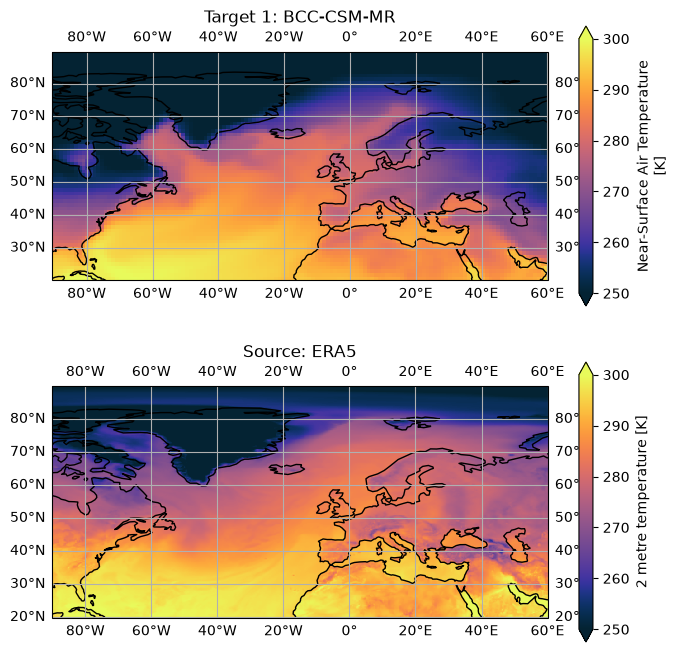

In [78]:
fig, ax = plt.subplots(2,1,
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    figsize=(8, 8),
)
tas_1 = target_1_converted_sliced["tas"].isel(time=0)
tas_1.plot(ax=ax[0], transform=ccrs.PlateCarree(), cmap=cmocean.cm.thermal, vmin=250, vmax=300)
ax[0].set_title("Target 1: BCC-CSM-MR")
ax[0].coastlines()
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
ax[0].gridlines(draw_labels=True)


source_t2m = source["t2m"].isel(valid_time=0)
source_t2m.plot(ax=ax[1], transform=ccrs.PlateCarree(), cmap=cmocean.cm.thermal, vmin=250, vmax=300)
ax[1].set_title("Source: ERA5")
ax[1].coastlines()
ax[1].set_xlabel("Longitude")
ax[1].set_ylabel("Latitude")
ax[1].gridlines(draw_labels=True)

plt.show()

In [79]:
transformer = Transformer.from_crs(4326, 4326, always_xy=True) ## defining the transformer from lat/lon (4326) to a distance based projection (3572)
transformer

<Concatenated Operation Transformer: noop>
Description: Null geographic offset from WGS 84 to WGS 84 (with axis order normalized for visualization)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)

In [83]:
# Build full 2D coordinate grids before reprojecting
lon_source_2d, lat_source_2d = np.meshgrid(source.longitude.values, source.latitude.values)
lon_target_2d, lat_target_2d = np.meshgrid(target_1_converted_sliced.lon.values, target_1_converted_sliced.lat.values)

x_source, y_source = transformer.transform(lon_source_2d, lat_source_2d)
x_target, y_target = transformer.transform(lon_target_2d, lat_target_2d)
shape_target = x_target.shape   # now (n_lat_target, n_lon_target) — a real 2D grid shape

In [85]:
print(x_source.shape, y_source.shape)

(281, 601) (281, 601)


In [87]:
print(x_target.shape, y_target.shape)
source_t2m = source["t2m"].isel(valid_time=0)
print(source_t2m.shape)

(62, 134) (62, 134)
(281, 601)


In [88]:
new_data = griddata(
    list(zip(x_source.ravel(), y_source.ravel())),
source['t2m'].isel(valid_time=0).values.ravel(),
    list(zip(x_target.ravel(), y_target.ravel())),
    method='linear'
)
new_data = new_data.reshape(shape_target)

In [89]:
new_data_da = xr.DataArray(
    new_data,
    coords={
        "lat": target_1_converted_sliced.lat,
        "lon": target_1_converted_sliced.lon,
    },
    dims=["lat", "lon"],
    name="t2m_regridded",
)

/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


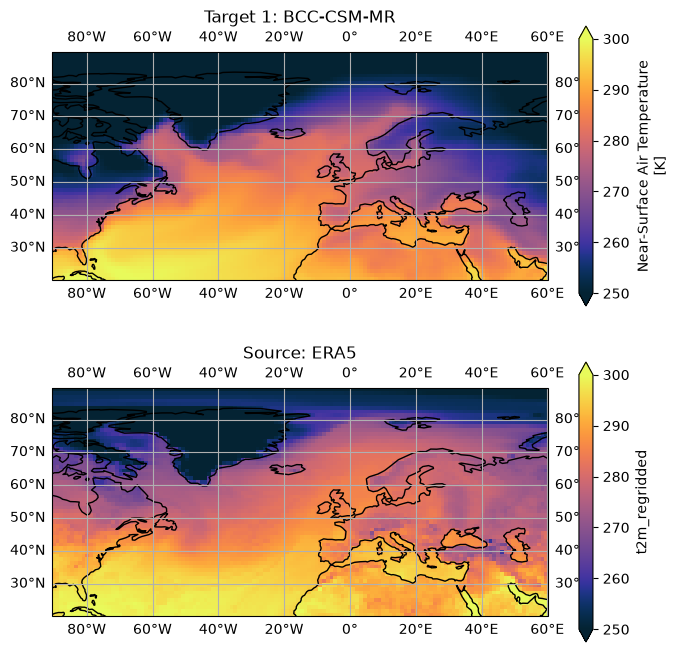

In [91]:
fig, ax = plt.subplots(2,1,
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    figsize=(8, 8),
)
tas_1 = target_1_converted_sliced["tas"].isel(time=0)
tas_1.plot(ax=ax[0], transform=ccrs.PlateCarree(), cmap=cmocean.cm.thermal, vmin=250, vmax=300)
ax[0].set_title("Target 1: BCC-CSM-MR")
ax[0].coastlines()
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
ax[0].gridlines(draw_labels=True)


new_data_da.plot(ax=ax[1], transform=ccrs.PlateCarree(), cmap=cmocean.cm.thermal, vmin=250, vmax=300)

ax[1].set_title("Source: ERA5")
ax[1].coastlines()
ax[1].set_xlabel("Longitude")
ax[1].set_ylabel("Latitude")
ax[1].gridlines(draw_labels=True)

plt.show()

/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


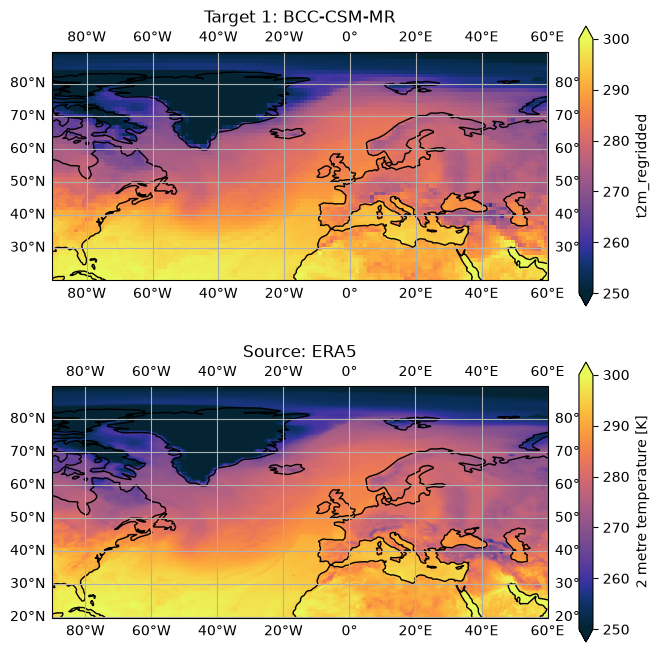

In [92]:
fig, ax = plt.subplots(2,1,
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    figsize=(8, 8),
)
new_data_da.plot(ax=ax[0], transform=ccrs.PlateCarree(), cmap=cmocean.cm.thermal, vmin=250, vmax=300)
ax[0].set_title("Target 1: BCC-CSM-MR")
ax[0].coastlines()
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
ax[0].gridlines(draw_labels=True)


source_t2m = source["t2m"].isel(valid_time=0)
source_t2m.plot(ax=ax[1], transform=ccrs.PlateCarree(), cmap=cmocean.cm.thermal, vmin=250, vmax=300)
ax[1].set_title("Source: ERA5")
ax[1].coastlines()
ax[1].set_xlabel("Longitude")
ax[1].set_ylabel("Latitude")
ax[1].gridlines(draw_labels=True)

plt.show()